# Case study: AI delivery conditions in the Grade 10 cohort

This notebook runs a full analysis on the synthetic Grade 10 cohort in `examples/grade10_cohort/`. The cohort has 40 fictional students, each randomly assigned to one of four versions of the AI assistant. Every student completed a biology question set, an essay and a geometry question set, with surveys before, in between and after.

`full_session_analysis.ipynb` documents each toolbox helper. This notebook uses them to answer one research question.

## Motivation

How an AI assistant is set up may change how students use it. It can tutor or just answer, students can be reminded to check it, and responses can arrive faster or slower. The platform lets researchers vary these settings as conditions and logs answers, grades, surveys, chats, request timings, keystrokes, clipboard use and tab switches.

## Research question

Does the way the AI assistant is delivered change how students use it, and does it affect their scores, their trust in AI and their perceived workload?

| Condition | Change |
|---|---|
| Control · Ordinary AI | none |
| Tutor · Explain your thinking | system prompt on the question and essay tasks: ask for the student's attempt first |
| Reminder · Verify the evidence | warning modal at the start that must be acknowledged |
| Delay · Three-second delay | each response is held back for 3 s |

## Hypotheses

- **H1 (manipulation check):** each condition was delivered as configured.
- **H2 (behaviour):** Tutor students send more prompts per question task; Delay students send fewer.
- **H3 (performance):** biology and geometry scores differ by condition, adjusted for baseline confidence and prior AI use.
- **H4 (perception):** Delay students report more disruption from waiting; the change in trust differs by condition; essay effort differs by condition.
- **H5 (exploratory):** students who paste AI text into answers score lower on free-text items.

## Plan

1. Load the export and check the study design.
2. Preprocess: apply exclusion rules and build one row per participant.
3. Describe the sample by condition.
4. Test H1–H5: count models for prompts, ANCOVA for scores and trust, rank tests for single ratings, Holm correction for H2–H4.
5. Check robustness: alternative samples, a permutation test, power.

The data is synthetic and groups have 8–12 participants, so treat the results as a demonstration of the method.

## 1. Setup

Data is read from the admin dashboard's **Export full sessions (JSON)** file with `load_export`. Install the extra statistics packages first:

```bash
python -m pip install -e "./research-toolbox[notebook,analysis]"
```

Set `RESEARCH_EXPORT_PATH` to use another export. The survey and task mapping in section 3 is specific to this workflow.

In [1]:
import os
import textwrap
from difflib import SequenceMatcher
from importlib.metadata import version
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import FTestAnovaPower

from research_toolbox import load_export

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.precision', 3)
pd.set_option('display.width', 160)
SEED = 20260922

# Works when Jupyter starts in the repository, toolbox, or notebooks directory.
PROJECT_ROOT = next(
    root for root in [Path.cwd() / 'research-toolbox', Path.cwd(), *Path.cwd().parents]
    if (root / 'examples' / 'grade10_cohort').is_dir()
)
cohort_exports = sorted((PROJECT_ROOT / 'examples' / 'grade10_cohort').glob('experiment-full-sessions-*.json'))
EXPORT_PATH = Path(os.environ.get('RESEARCH_EXPORT_PATH', cohort_exports[-1])).expanduser()

data = load_export(EXPORT_PATH)
print('Export:', EXPORT_PATH.name)
display(pd.Series(data.metadata, name='value').to_frame())
print('Validation warnings:', data.validation_warnings or 'none')
assert data.metadata['anonymized'], 'Use an anonymized export for analysis.'

Export: experiment-full-sessions-20260930-115623.json


,value
schema_version,1.0
exported_at,2026-09-30T11:56:23.658670+00:00
anonymized,True
timestamp_units,{'experiment_session_plan_task_submission_telemetry': 'nanoseconds...


Validation warnings: none


Each condition has one colour in all charts, and Control is grey. Dot plots show each participant plus the condition mean with a 95% CI.

In [2]:
CONDITIONS = ['Control', 'Tutor', 'Reminder', 'Delay']
CONDITION_KEYS = {
    'condition-control': 'Control', 'condition-tutor': 'Tutor',
    'condition-reminder': 'Reminder', 'condition-delay': 'Delay',
}
COLORS = {'Control': '#6f6e69', 'Tutor': '#2a78d6', 'Reminder': '#1baf7a', 'Delay': '#eb6834'}
INK, MUTED, GRID = '#1f1f1e', '#6f6e69', '#e4e3df'
BLUES = LinearSegmentedColormap.from_list('blues', ['#f0efec', '#9ec5f4', '#3987e5', '#1c5cab', '#0d366b'])

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110, 'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'axes.grid.axis': 'y', 'grid.color': GRID, 'grid.linewidth': 0.8,
    'xtick.color': INK, 'ytick.color': INK, 'legend.frameon': False,
})


def label_conditions(frame):
    # Short, ordered condition labels from the platform's stable condition keys.
    labels = frame['condition_key'].map(CONDITION_KEYS)
    return frame.assign(condition=pd.Categorical(labels, categories=CONDITIONS, ordered=True))


def ci95(values):
    v = pd.Series(values, dtype='float64').dropna()
    if len(v) < 2:
        return np.nan, np.nan, np.nan
    half = stats.t.ppf(0.975, len(v) - 1) * v.std(ddof=1) / np.sqrt(len(v))
    return v.mean(), v.mean() - half, v.mean() + half


def strip_by_condition(ax, frame, column, ylabel, title=None, seed=0):
    # Each participant as a dot; the condition mean and 95% CI to the right.
    jitter = np.random.default_rng(seed)
    for i, cond in enumerate(CONDITIONS):
        vals = frame.loc[frame['condition'] == cond, column].astype('float64').dropna()
        ax.scatter(i + jitter.uniform(-0.13, 0.13, len(vals)), vals, s=26, color=COLORS[cond], alpha=0.8,
                   edgecolor='white', linewidth=0.8, zorder=2)
        mean, lo, hi = ci95(vals)
        if not np.isnan(mean):
            ax.errorbar(i + 0.3, mean, yerr=[[mean - lo], [hi - mean]], fmt='o', color=INK, ms=4.5, lw=1.6, zorder=3)
    ax.set_xticks(range(len(CONDITIONS)), CONDITIONS)
    ax.set_xlim(-0.5, len(CONDITIONS) - 0.4)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)


def condition_terms(result):
    return [name for name in result.params.index if name.startswith('C(condition')]


def contrast_table(result, exponentiate=False, scale=1.0):
    # Condition contrasts against Control with 95% CIs (robust if the model was fitted that way).
    names = condition_terms(result)
    ci = result.conf_int().loc[names]
    table = pd.DataFrame({
        'estimate': result.params[names], 'ci_low': ci[0], 'ci_high': ci[1], 'p': result.pvalues[names],
    })
    table.index = [name.split('[T.')[-1].rstrip(']') for name in names]
    if exponentiate:
        table[['estimate', 'ci_low', 'ci_high']] = np.exp(table[['estimate', 'ci_low', 'ci_high']])
    else:
        table[['estimate', 'ci_low', 'ci_high']] *= scale
    return table


def condition_wald(result):
    # Joint test that all condition contrasts are zero, using the model's covariance (e.g. HC3).
    # Linear models report an F statistic; count models a Wald chi-squared.
    names = list(result.params.index)
    restriction = np.eye(len(names))[[names.index(name) for name in condition_terms(result)]]
    test = result.wald_test(restriction, scalar=True, use_f=isinstance(result.model, sm.OLS))
    return float(np.squeeze(test.statistic)), float(np.squeeze(test.pvalue))

## 2. Study design

The export includes the experiment configuration: the conditions, their allocation and which change each one applies.

In [3]:
conditions = data.conditions.assign(condition=lambda f: f['source_condition_key'].map(CONDITION_KEYS))
def by_condition(table):
    return table.merge(conditions[['condition_id', 'condition']], on='condition_id').set_index('condition')


injections, modals, timings = (
    by_condition(t) for t in (data.prompt_injections, data.warning_modals, data.response_timings))

tasks = data.task_progress()
task_titles = tasks.drop_duplicates('plan_item_id').set_index('plan_item_id')['title']
scopes = by_condition(data.condition_task_scopes).assign(task=lambda f: f['plan_item_id'].map(task_titles))

design = conditions.set_index('condition')[['is_control', 'allocation_percent']].reindex(CONDITIONS)
design['prompt_injection'] = injections['enabled']
design['injection_tasks'] = scopes.groupby(level=0)['task'].agg(lambda t: ', '.join(sorted(t)))
design['warning_modal'] = modals['enabled'].astype(str) + ' (' + modals['cadence'] + ')'
design['response_timing'] = timings['mode'] + timings['delay_seconds'].map(lambda s: '' if pd.isna(s) else f' {s:g} s')
display(design.fillna('–'))

print('Tutor instruction (start):', textwrap.shorten(injections.loc['Tutor', 'instruction'], 260))
print('Reminder modal:', modals.loc['Reminder', 'title'], '–', textwrap.shorten(modals.loc['Reminder', 'message'], 200))

,is_control,allocation_percent,prompt_injection,injection_tasks,warning_modal,response_timing
condition,,,,,,
Control,True,25,False,–,False (BEGINNING),NORMAL
Tutor,False,25,True,"02 · Biology: Evidence about osmosis, 03 · English: A library inve...",False (BEGINNING),NORMAL
Reminder,False,25,False,–,True (BEGINNING),NORMAL
Delay,False,25,False,–,False (BEGINNING),DELAYED 3 s


Tutor instruction (start): You are helping a Grade 10 student during an AI-assisted learning exam. For each new problem or writing task, ask for the student’s attempt or current reasoning if they have not provided it. Give one concise hint or guiding question at a time. Ask the [...]
Reminder modal: Check the reasoning – AI can make mistakes. Check its reasoning against the question, diagram, or supplied evidence before using it. Be ready to explain your answer.


All participants do the same six tasks in a fixed order. Question and essay tasks allow up to 100 AI prompts each.

In [4]:
TASK_LABELS = {0: 'Background survey', 1: 'Biology', 2: 'Essay', 3: 'Check-in survey', 4: 'Geometry', 5: 'Post survey'}
display(tasks.drop_duplicates('position').set_index('position')[['title', 'task_type', 'llm_prompt_budget']])

,title,task_type,llm_prompt_budget
position,,,
0,01 · Background survey,SURVEY,None
1,02 · Biology: Evidence about osmosis,QUESTION,"{'mode': 'TASK', 'limit': 100, 'question_limits': {}}"
2,03 · English: A library investment argument,ESSAY,"{'mode': 'TASK', 'limit': 100, 'question_limits': {}}"
3,04 · Essay and effort check-in,SURVEY,None
4,05 · Geometry: Explain and adapt,QUESTION,"{'mode': 'TASK', 'limit': 100, 'question_limits': {}}"
5,06 · Post-exam survey,SURVEY,None


### Participant flow

Assigned, started and finished, by condition. `state` alone is not enough: one student finalized every task but never clicked *Finish*, so their state is `THANK_YOU_REQUIRED`.

outcome,Assigned,Completed,"All tasks done, Finish not clicked",Dropped out,Never started
condition,,,,,
Control,8,6,1,0,1
Tutor,9,8,0,1,0
Reminder,11,10,0,1,0
Delay,12,11,0,1,0


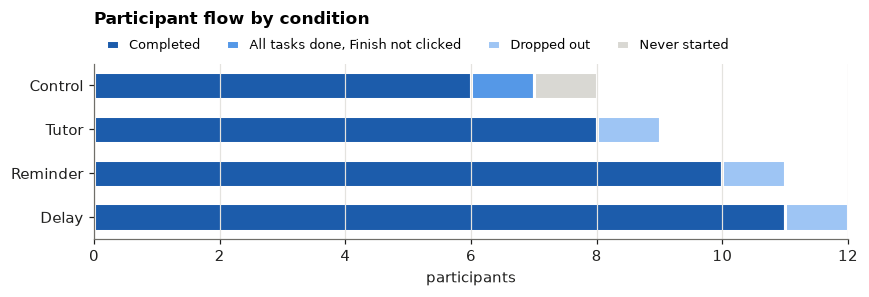

In [5]:
activity = label_conditions(data.session_activity())
OUTCOMES = ['Completed', 'All tasks done, Finish not clicked', 'Dropped out', 'Never started']


def flow_outcome(row):
    if row['tasks_finished'] == 0:
        return 'Never started'
    if row['state'] == 'IN_PROGRESS':
        return 'Dropped out'
    return 'Completed' if row['state'] == 'COMPLETED' else 'All tasks done, Finish not clicked'


activity['outcome'] = activity.apply(flow_outcome, axis=1)
flow = pd.crosstab(activity['condition'], activity['outcome']).reindex(columns=OUTCOMES, fill_value=0)
flow.insert(0, 'Assigned', flow.sum(axis=1))
display(flow)

fig, ax = plt.subplots(figsize=(8, 2.8))
shades = ['#1c5cab', '#5598e7', '#9ec5f4', '#d9d8d3']
left = np.zeros(len(flow))
for outcome, shade in zip(OUTCOMES, shades):
    ax.barh(flow.index.astype(str), flow[outcome], left=left, color=shade, edgecolor='white', linewidth=2,
            label=outcome, height=0.62)
    left += flow[outcome].to_numpy()
ax.invert_yaxis()
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('participants')
ax.set_title('Participant flow by condition', pad=26)
ax.legend(ncols=4, loc='lower left', bbox_to_anchor=(0, 1.0), fontsize=8.5, handlelength=1)
plt.tight_layout()
plt.show()

The 25% allocation gave groups of 8, 9, 11 and 12, so comparisons below use means rather than totals.

## 3. Preprocessing

The goal is one table with one row per participant, plus a log of flags.

### 3a. Rules

These were fixed before looking at outcomes.

| Issue | Detection | Handling |
|---|---|---|
| Never started | no finished tasks | excluded |
| Dropped out | state `IN_PROGRESS` | keep finalized tasks; later outcomes missing |
| Finish not clicked | `THANK_YOU_REQUIRED`, all tasks finalized | kept |
| Low effort | 2 of: active time < 20 min, same answer on every rating, essay < 100 words | excluded in robustness check |
| No telemetry | no telemetry summary | telemetry measures missing, not 0 |
| Paste-heavy | > 1,000 characters pasted from AI replies | excluded in robustness check |
| Scores pending | items `AWAITING_REVIEW` | items left out of score and maximum |
| Idle time | long absences | use active time |
| Clock skew | browser clock differs from server | use server timestamps for latency |

### 3b. Time on task

The longest session is mostly one long absence, so time on task uses `active_min` instead of wall-clock time.

In [6]:
activity['telemetry_ok'] = activity['has_telemetry_summary'].fillna(False).astype(bool)
activity['wall_min'] = activity['wall_seconds'] / 60
activity['active_min'] = activity['active_seconds'] / 60
# Without client telemetry the platform cannot see absences, so away time is unknown (not zero)
# and active time falls back to wall-clock time, an upper bound.
activity['away_min'] = (activity['away_seconds'] / 60).where(activity['telemetry_ok'])
display(activity.sort_values('wall_min', ascending=False)[
    ['participant_id', 'condition', 'state', 'wall_min', 'away_min', 'active_min', 'telemetry_ok']
].head(5))

,participant_id,condition,state,wall_min,away_min,active_min,telemetry_ok
10,P-6032C4E88957,Control,COMPLETED,210.400,135.271,75.128,True
11,P-C24E90C26EAC,Tutor,COMPLETED,81.625,1.056,80.569,True
13,P-37EC0E3D953E,Reminder,COMPLETED,80.944,0.542,80.402,True
9,P-11300019608A,Reminder,COMPLETED,75.133,2.833,72.300,True
32,P-7C33B6F8FBE4,Tutor,COMPLETED,73.485,1.330,72.155,True


`focus_periods()` lists each time a student left the tab, with the title of the tab they switched to. Grouping titles separates off-task browsing from calculator or search use.

,absences,participants,median_s,total_min
destination_kind,,,,
Calculator or search,16,16,22.322,6.542
Off-task,30,19,48.630,158.923
Other,40,25,2.469,3.168


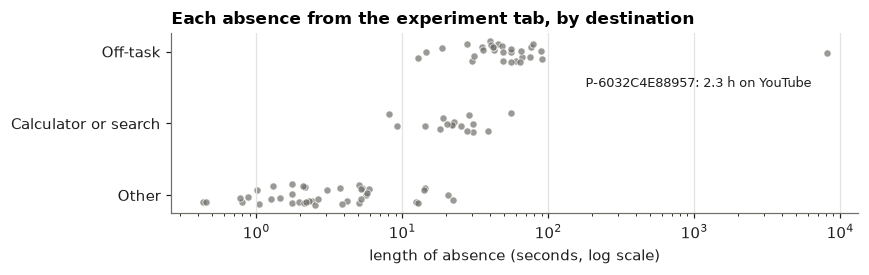

In [7]:
focus = label_conditions(data.focus_periods())
OFF_TASK = ('instagram', 'youtube', 'tiktok', 'snapchat', 'spotify', 'gmail', 'inbox')
TOOLS = ('desmos', 'calculator', 'google search')


def destination_kind(title):
    title = str(title or '').lower()
    if any(word in title for word in OFF_TASK):
        return 'Off-task'
    if any(word in title for word in TOOLS):
        return 'Calculator or search'
    return 'Other' if title else 'Unknown'


focus['destination_kind'] = focus['destination_title'].map(destination_kind)
focus['away_s'] = focus['away_ms'] / 1000
display(focus.groupby('destination_kind').agg(
    absences=('away_s', 'size'), participants=('session_id', 'nunique'),
    median_s=('away_s', 'median'), total_min=('away_s', lambda s: s.sum() / 60),
))

kinds = ['Off-task', 'Calculator or search', 'Other']
fig, ax = plt.subplots(figsize=(8, 2.6))
jitter = np.random.default_rng(1)
for i, kind in enumerate(kinds):
    rows = focus[focus['destination_kind'] == kind]
    ax.scatter(rows['away_s'], i + jitter.uniform(-0.15, 0.15, len(rows)), s=22, color=MUTED, alpha=0.7,
               edgecolor='white', linewidth=0.6)
idle = focus.loc[focus['away_s'].idxmax()]
ax.annotate(f"{idle['participant_id']}: {idle['away_s'] / 3600:.1f} h on {idle['destination_title']}",
            (idle['away_s'], kinds.index(idle['destination_kind'])), xytext=(-10, -16), textcoords='offset points',
            ha='right', va='top', fontsize=8.5, color=INK)
ax.set_xscale('log')
ax.set_yticks(range(len(kinds)), kinds)
ax.invert_yaxis()
ax.grid(axis='x', visible=True)
ax.grid(axis='y', visible=False)
ax.set_xlabel('length of absence (seconds, log scale)')
ax.set_title('Each absence from the experiment tab, by destination')
plt.tight_layout()
plt.show()

off_task_min = focus[focus['destination_kind'] == 'Off-task'].groupby('session_id')['away_s'].sum() / 60

### 3c. Scores

A task score is points earned divided by points available, over graded items only. Items awaiting review are left out, and draft submissions from dropouts get no score.

In [8]:
answers = label_conditions(data.question_answers())
answers['subject'] = answers['task_position'].map({1: 'biology', 4: 'geometry'})
answers['graded'] = answers['grading_status'].eq('GRADED') & answers['submission_status'].eq('FINALIZED')
display(pd.crosstab([answers['submission_status'], answers['grading_status']], answers['subject']))

graded = answers[answers['graded']]


def score_pct(frame, by):
    points = frame.groupby(by)[['effective_score', 'max_score']].sum()
    return 100 * points['effective_score'].astype('float64') / points['max_score'].astype('float64')


scores = score_pct(graded, ['session_id', 'subject']).unstack().add_suffix('_pct')
scores['freetext_pct'] = score_pct(graded[graded['grading_mode'] == 'MANUAL'], 'session_id')
scores['auto_pct'] = score_pct(graded[graded['grading_mode'] == 'AUTOMATIC'], 'session_id')
scores['items_awaiting_review'] = answers[answers['grading_status'] == 'AWAITING_REVIEW'].groupby('session_id').size()
scores['items_awaiting_review'] = scores['items_awaiting_review'].fillna(0).astype(int)
scores.describe().T

subject                            biology  geometry
submission_status grading_status                    
DRAFT             NOT_STARTED            5        10
FINALIZED         AWAITING_REVIEW        2         3
                  GRADED               188       357

,count,mean,std,min,25%,50%,75%,max
subject,,,,,,,,
biology_pct,38.0,78.553,22.350,12.500,75.000,83.750,95.000,100.0
geometry_pct,36.0,82.569,22.186,2.500,82.500,89.375,95.312,100.0
freetext_pct,38.0,78.427,21.015,6.250,72.656,83.854,95.312,100.0
auto_pct,38.0,82.895,22.908,5.357,83.036,91.071,96.429,100.0
items_awaiting_review,38.0,0.132,0.578,0.000,0.000,0.000,0.000,3.0


### 3d. Surveys

Confidence and trust were asked in both the background and post surveys. The table maps each rating item to a variable name.

In [9]:
survey = label_conditions(data.survey_answers())
SCALE_ITEMS = {
    (0, 2): 'conf_pre', (0, 3): 'trust_pre', (3, 1): 'essay_effort', (3, 2): 'tiredness',
    (5, 0): 'conf_post', (5, 1): 'trust_post', (5, 2): 'wait_interrupt',
}
ITEM_KEY = ['task_position', 'question_position']
item_text = survey.drop_duplicates(ITEM_KEY).set_index(ITEM_KEY)
item_map = pd.Series(SCALE_ITEMS, name='variable').rename_axis(ITEM_KEY)
display(item_map.to_frame().join(item_text[['prompt', 'required', 'scale_low_label', 'scale_high_label']]))

scale = survey[survey['question_type'] == 'SCALE'].copy()
scale['variable'] = [SCALE_ITEMS.get(key) for key in zip(scale['task_position'], scale['question_position'])]
survey_wide = scale.dropna(subset=['variable']).pivot_table(
    index='session_id', columns='variable', values='scale_answer', aggfunc='first')
survey_wide['trust_change'] = survey_wide['trust_post'] - survey_wide['trust_pre']
survey_wide['conf_change'] = survey_wide['conf_post'] - survey_wide['conf_pre']

# Straight-lining: every rating answered identically (a low-effort signal).
answered = scale.dropna(subset=['scale_answer']).groupby('session_id')['scale_answer']
survey_wide['straightlined'] = (answered.nunique() == 1) & (answered.count() >= 5)

variable                                                                 prompt  required             scale_low_label  \
task_position question_position                                                                                                                                
0             2                        conf_pre  How confident are you that you can explain your own answers to Gra...      True    1 — Not at all confident   
              3                       trust_pre  How much do you trust an AI assistant’s answer to a school task be...      True  1 — Do not trust it at all   
3             1                    essay_effort                  How much mental effort did writing the essay require?      True      1 — Very little effort   
              2                       tiredness                              How mentally tired do you feel right now?      True        1 — Not at all tired   
5             0                       conf_post  How confident are you that you can explain your own answers to Gra...      True    1 — Not at all confident   
              1                      trust_post  How much do you trust an AI assistant’s answer to a school task be...      True  1 — Do not trust it at all   
              2                  wait_interrupt  When you used AI during this exam, how much did waiting for its re...     False              1 — Not at all   

                                        scale_high_label  
task_position question_position                           
0             2                  5 — Extremely confident  
              3                  5 — Trust it completely  
3             1                     5 — Very high effort  
              2                      5 — Extremely tired  
5             0                  5 — Extremely confident  
              1                  5 — Trust it completely  
              2                         5 — A great deal

Prior AI use is coded 0–4 from the position of the chosen option, read from `survey_choices`.

In [10]:
def first_choice(frame, task_position, question_position):
    rows = frame[(frame['task_position'] == task_position) & (frame['question_position'] == question_position)]
    return rows.set_index('session_id')['selected_choice_ids'].map(lambda ids: ids[0] if len(ids) else None)


choices = data.survey_choices.set_index('id')
ai_use_choice = first_choice(survey, 0, 1)
survey_wide['ai_use_freq'] = ai_use_choice.map(choices['position']).astype('float64')
survey_wide['essay_ai_role'] = first_choice(survey, 3, 0).map(choices['text'])
ai_use_options = choices.loc[choices['survey_question_id'] == item_text.loc[(0, 1), 'survey_question_id']]
chosen = ai_use_choice.map(choices['text']).value_counts()
display(ai_use_options.set_index('position')[['text']].assign(participants=lambda f: f['text'].map(chosen).fillna(0)))

,text,participants
position,,
0,Never,0
1,Once or twice in the month,4
2,About once a week,21
3,Several days a week,10
4,Daily or almost daily,4


### 3e. AI use

Prompts are user messages per task from `chat_usage_summary()`. `llm_request_timing()` has one row per model request. The table lists sessions where the two sources differ.

In [11]:
usage = data.chat_usage_summary(by=('session_id', 'task_id')).merge(
    tasks[['session_id', 'task_id', 'task_type']], on=['session_id', 'task_id'], how='left')
prompts = usage.pivot_table(index='session_id', columns='task_type', values='user_messages', aggfunc='sum')
prompts = prompts.reindex(columns=['QUESTION', 'ESSAY']).rename(
    columns={'QUESTION': 'prompts_question', 'ESSAY': 'prompts_essay'})

started = tasks[tasks['started_at'].notna()]
ai_use = pd.DataFrame({
    'question_tasks_started': started[started['task_type'] == 'QUESTION'].groupby('session_id').size(),
}).join(prompts).fillna(0)
ai_use['prompts_total'] = ai_use['prompts_question'] + ai_use['prompts_essay']
ai_use['prompts_per_qtask'] = ai_use['prompts_question'] / ai_use['question_tasks_started'].replace(0, np.nan)

requests = label_conditions(data.llm_request_timing())
integrity = requests.groupby('session_id').agg(
    requests=('llm_request_id', 'size'), unique_prompts=('prompt_number', 'nunique'),
    failed=('status', lambda s: s.eq('FAILED').sum()), cancelled=('status', lambda s: s.eq('CANCELLED').sum()),
    navigated_away=('navigated_away', 'sum'),
).join(usage.groupby('session_id')['user_messages'].sum())
mismatch = integrity[(integrity['requests'] != integrity['unique_prompts']) | (integrity['cancelled'] > 0)
                     | (integrity['user_messages'] != integrity['unique_prompts'])]
display(mismatch.join(activity.set_index('session_id')[['participant_id', 'condition']]))

,requests,unique_prompts,failed,cancelled,navigated_away,user_messages,participant_id,condition
session_id,,,,,,,,
6a2bbfc6-0fdb-4623-9ef2-72416af65e8f,7,7,0,1,1,7,P-BDB1EE4C6543,Delay
9925a474-ea64-4ce4-9c7e-de5732c909fa,5,4,1,0,0,4,P-88F357702936,Delay
d48d6399-cea8-4243-a8a8-5988b9a9ffef,6,6,0,1,1,6,P-14F283031AFA,Reminder


The differences come from one failed request that was retried and two requests cancelled by a page reload. These still count as prompts, but latency uses `COMPLETED` requests only.

`client_*` timestamps come from the student's browser clock, so a response can appear to arrive before the server sent it:

In [12]:
completed = requests[requests['status'] == 'COMPLETED']
skewed = (completed['client_first_visible_ms'] < completed['server_first_emit_ms']).mean()
print(f'{skewed:.0%} of completed requests appear on the client before the server emitted them.')
print('Latency analyses therefore use server_first_emit_ms (request received -> first output sent).')
latency = completed.groupby('session_id')['server_first_emit_ms'].median().rename('median_first_emit_s') / 1000

58% of completed requests appear on the client before the server emitted them.
Latency analyses therefore use server_first_emit_ms (request received -> first output sent).


### 3f. Telemetry

- `keystroke_summary()`: keystrokes, deletions and pauses over 2 s per task and field.
- `clipboard_events()`: copy, cut and paste events with their text.

A paste counts as AI-sourced if at least 60% of its text matches an AI reply from the same session.

In [13]:
keys = data.keystroke_summary()
essay_keys = keys[keys['field_context'] == 'essay'].groupby('session_id')[
    ['keystrokes', 'printable', 'backspaces', 'pauses']].sum()
essays = data.essay_texts()
submitted = essays[essays['status'] == 'submitted'].set_index('session_id')
writing = pd.DataFrame({
    'essay_words': submitted['word_count'].astype('float64'),
    'essay_deletion_ratio': essay_keys['backspaces'] / essay_keys['keystrokes'],
    'essay_pauses_per_100w': 100 * essay_keys['pauses'] / submitted['word_count'],
    # Share of the essay's characters that were typed rather than pasted (capped at 1: revisions add keystrokes).
    'essay_typed_share': (essay_keys['printable'] / submitted['calculated_character_count']).clip(upper=1),
})

replies = data.chat_transcript().query("role == 'assistant'")


def ai_overlap(row):
    text = row['text_value'] or ''
    best = 0.0
    for reply in replies.loc[replies['session_id'] == row['session_id'], 'text'].dropna():
        match = SequenceMatcher(None, text, reply, autojunk=False).find_longest_match(0, len(text), 0, len(reply))
        best = max(best, match.size / max(len(text), 1))
    return best


pastes = label_conditions(data.clipboard_events().query("event_type == 'paste'"))
pastes['ai_overlap'] = pastes.apply(ai_overlap, axis=1)
pastes['from_ai'] = pastes['ai_overlap'] >= 0.6
display(pastes.groupby(['participant_id', 'condition', 'field_context'], observed=True).agg(
    pastes=('text_length', 'size'), chars=('text_length', 'sum'), from_ai=('from_ai', 'mean')).unstack('field_context'))

ai_pasted = pastes[pastes['from_ai']].pivot_table(
    index='session_id', columns='field_context', values='text_length', aggfunc='sum')
ai_pasted = ai_pasted.reindex(columns=['question', 'essay']).add_prefix('ai_paste_chars_')

pastes          chars          from_ai         
field_context             essay question essay question   essay question
participant_id condition                                                
P-11300019608A Reminder       1        1   103       66     1.0      1.0
P-43924A3D78A3 Delay          2        5   708     1309     1.0      1.0
P-C96E0F259C90 Delay          1        3  1644     1409     1.0      1.0
P-CB6641F149FE Control        1        5  1175     1491     1.0      1.0
P-D5129A0043A8 Control        1     <NA>    52     <NA>     1.0      NaN

### 3g. Participant table and flags

Tables are joined on `session_id`. Telemetry counts are set to 0 only for sessions that have telemetry.

In [14]:
df = (
    label_conditions(data.session_context()).set_index('session_id')[['participant_id', 'condition', 'state']]
    .join(activity.set_index('session_id')[['tasks_finished', 'telemetry_ok', 'wall_min', 'active_min', 'away_min']])
    .join(off_task_min.rename('off_task_min'))
    .join(scores).join(survey_wide).join(ai_use).join(latency).join(writing).join(ai_pasted)
    .join(data.session_overview().set_index('session_id')['total_tokens'].astype('float64'))
)
telemetry_counts = ['off_task_min', 'ai_paste_chars_question', 'ai_paste_chars_essay']
df[telemetry_counts] = df[telemetry_counts].fillna(0).where(df['telemetry_ok'])
df['ai_paste_chars'] = df['ai_paste_chars_question'] + df['ai_paste_chars_essay']

flags = pd.DataFrame(index=df.index)
flags['never_started'] = df['tasks_finished'].eq(0)
flags['dropped_out'] = df['state'].eq('IN_PROGRESS')
flags['finish_not_clicked'] = df['state'].eq('THANK_YOU_REQUIRED')
low_effort_signals = (df['active_min'].lt(20).astype(int) + df['straightlined'].fillna(False).astype(int)
                      + df['essay_words'].lt(100).astype(int))
flags['low_effort'] = low_effort_signals.ge(2) & ~flags['never_started']
flags['no_telemetry'] = ~df['telemetry_ok'] & ~flags['never_started']
flags['paste_heavy'] = df['ai_paste_chars'].gt(1000)
flags['scores_pending'] = df['items_awaiting_review'].gt(0)
flags = flags.astype('boolean').fillna(False).astype(bool)

flag_log = flags[flags.any(axis=1)].join(df[['participant_id', 'condition', 'state']])
flag_log['flags'] = flag_log[flags.columns].apply(lambda row: ', '.join(row.index[row]), axis=1)
display(flag_log[['participant_id', 'condition', 'state', 'flags']].sort_values('condition'))
display(flags.sum().rename('participants').to_frame())

,participant_id,condition,state,flags
session_id,,,,
f2cb8d39-53a0-434d-b707-96d9ac79e523,P-CB6641F149FE,Control,COMPLETED,paste_heavy
dec89786-96c2-4a5e-956f-b45350f09085,P-1CC95996A619,Control,COMPLETED,scores_pending
2ab129eb-449c-4483-a597-463b2129f27a,P-686D3F43E1FB,Control,THANK_YOU_REQUIRED,finish_not_clicked
3ae416fb-43d1-4373-ae72-d376525be48c,P-C1D5C947BDB8,Control,TASK_REQUIRED,never_started
56bc0a2b-e787-44b6-8fcb-b70fc038ca4a,P-3BE0F1CFF7C8,Tutor,IN_PROGRESS,dropped_out
f55f81f9-0f12-4d89-a969-b5d00cceec1e,P-EED7E3B0F9D8,Reminder,COMPLETED,no_telemetry
b11a12b6-65bd-4f9f-a390-4db471142f95,P-7CB5853CA80F,Reminder,IN_PROGRESS,dropped_out
0e27abda-166e-493c-9203-471bb8bdc5eb,P-C96E0F259C90,Delay,COMPLETED,paste_heavy
671a43ed-ce1d-4842-8531-667947ddf3d9,P-45C4C959F35E,Delay,COMPLETED,scores_pending


,participants
never_started,1
dropped_out,3
finish_not_clicked,1
low_effort,1
no_telemetry,1
paste_heavy,3
scores_pending,2


The flags match the problem participants in the cohort README; the idle outlier is handled by active time instead. The paste rule also catches P-43924A3D78A3 (about 2,000 pasted characters), who is not in the README list.

Only the student who never started is excluded. The other flags are used in section 10.

In [15]:
analysis = df[~flags['never_started']].copy()
KEY_VARIABLES = ['conf_pre', 'trust_pre', 'ai_use_freq', 'active_min', 'prompts_per_qtask', 'biology_pct',
                 'geometry_pct', 'freetext_pct', 'trust_post', 'wait_interrupt', 'essay_effort', 'essay_typed_share',
                 'ai_paste_chars', 'median_first_emit_s']
print(f'Analysis sample: {len(analysis)} of {len(df)} participants')
display(analysis[KEY_VARIABLES].isna().sum().rename('missing').to_frame().T)

Analysis sample: 39 of 40 participants


,conf_pre,trust_pre,ai_use_freq,active_min,prompts_per_qtask,biology_pct,geometry_pct,freetext_pct,trust_post,wait_interrupt,essay_effort,essay_typed_share,ai_paste_chars,median_first_emit_s
missing,0,0,0,0,0,1,3,1,3,8,2,3,1,2


Missing values come from dropouts, the optional *waiting interrupted* question, the session without telemetry, and two students who never used the AI.

## 4. Descriptives

Means (SD) by condition. The baseline rows are similar across groups, and the models adjust for them anyway.

In [16]:
TABLE1 = {
    'conf_pre': 'Baseline confidence (1–5)', 'trust_pre': 'Baseline trust in AI (1–5)',
    'ai_use_freq': 'Prior AI use (0–4)', 'active_min': 'Active minutes', 'prompts_total': 'Prompts, all tasks',
    'total_tokens': 'Tokens (estimated)', 'biology_pct': 'Biology score (%)', 'geometry_pct': 'Geometry score (%)',
    'freetext_pct': 'Free-text items (%)', 'trust_post': 'Post trust in AI (1–5)',
    'essay_effort': 'Essay mental effort (1–5)', 'wait_interrupt': 'Waiting interrupted (1–5)',
}


def mean_sd(values):
    values = values.astype('float64').dropna()
    return f'{values.mean():.2f} ({values.std():.2f})' if len(values) > 1 else '–'


table1 = analysis.groupby('condition', observed=True)[list(TABLE1)].agg(mean_sd).T.rename(index=TABLE1)
table1.loc['n'] = analysis.groupby('condition', observed=True).size().astype(str)
display(table1.iloc[[-1, *range(len(TABLE1))]])

condition,Control,Tutor,Reminder,Delay
n,7,9,11,12
Baseline confidence (1–5),3.14 (0.90),3.11 (0.78),3.00 (0.77),3.17 (0.72)
Baseline trust in AI (1–5),3.14 (0.90),3.22 (0.83),3.09 (0.94),2.92 (0.79)
Prior AI use (0–4),2.43 (0.98),2.44 (1.01),2.55 (0.69),2.08 (0.67)
Active minutes,57.68 (11.39),60.75 (11.06),58.84 (18.53),50.14 (17.69)
"Prompts, all tasks",5.29 (3.99),7.89 (3.41),6.45 (2.58),4.50 (3.26)
Tokens (estimated),1969.29 (3102.70),5054.00 (2578.03),2024.00 (1507.10),1555.50 (2172.34)
Biology score (%),86.07 (7.48),79.44 (25.27),77.25 (24.17),74.58 (25.54)
Geometry score (%),85.54 (11.72),89.53 (13.21),81.38 (23.06),76.70 (30.91)
Free-text items (%),81.99 (10.90),84.26 (15.94),78.12 (21.80),72.22 (27.73)


`condition_summary()` gives a quick version from the dashboard summaries. It uses wall-clock time, so the idle student adds more than 20 minutes to the Control mean. It also includes the student who never started.

In [17]:
quick = data.condition_summary(metrics=['session_duration', 'prompts', 'total_tokens'])
quick = quick.assign(condition=quick['condition_key'].map(CONDITION_KEYS)).set_index('condition').reindex(CONDITIONS)
quick['session_duration_mean_min'] = quick['session_duration_mean'] / 60
quick['active_min_mean (this notebook)'] = analysis.groupby('condition', observed=True)['active_min'].mean()
display(quick[['session_count', 'session_duration_mean_min', 'active_min_mean (this notebook)', 'prompts_mean',
               'total_tokens_mean']])

,session_count,session_duration_mean_min,active_min_mean (this notebook),prompts_mean,total_tokens_mean
condition,,,,,
Control,8,80.856,57.682,4.625,1723.125
Tutor,9,63.082,60.746,7.889,5054.0
Reminder,11,64.881,58.837,6.455,2024.0
Delay,12,53.676,50.141,4.5,1555.5


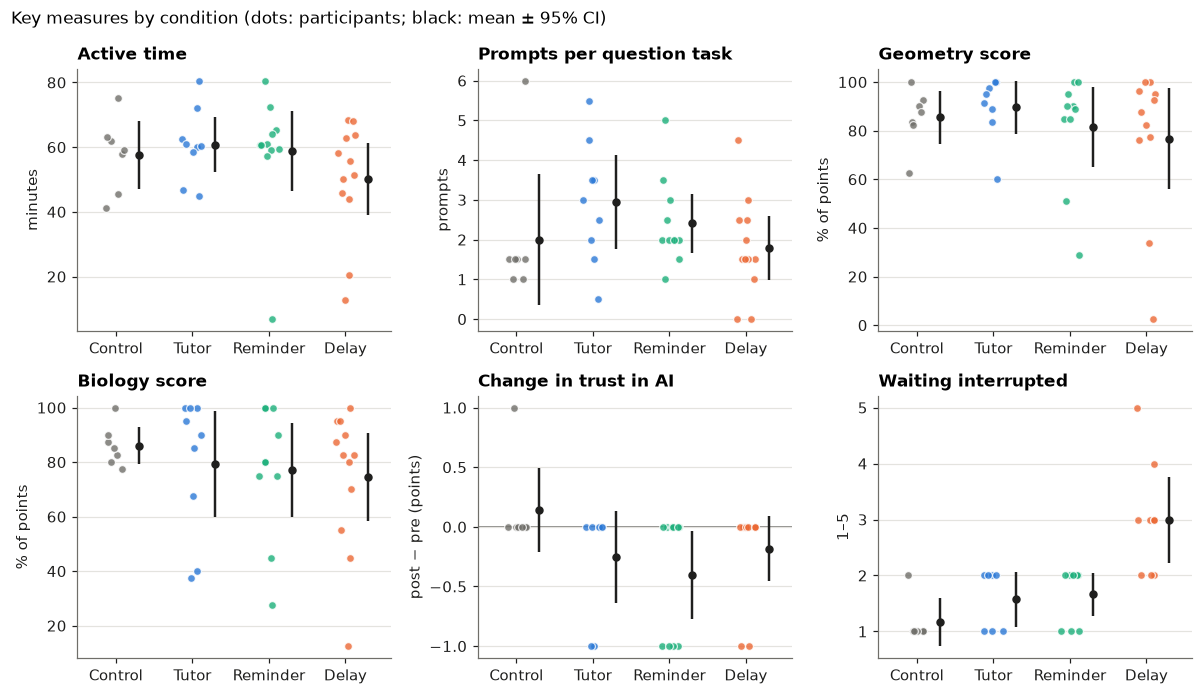

In [18]:
OVERVIEW = [
    ('active_min', 'minutes', 'Active time'), ('prompts_per_qtask', 'prompts', 'Prompts per question task'),
    ('geometry_pct', '% of points', 'Geometry score'), ('biology_pct', '% of points', 'Biology score'),
    ('trust_change', 'post − pre (points)', 'Change in trust in AI'), ('wait_interrupt', '1–5', 'Waiting interrupted'),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.4))
for seed, (ax, (column, ylabel, title)) in enumerate(zip(axes.flat, OVERVIEW)):
    strip_by_condition(ax, analysis, column, ylabel, title, seed=seed)
axes[1, 1].axhline(0, color=MUTED, lw=1, zorder=1)
fig.suptitle('Key measures by condition (dots: participants; black: mean ± 95% CI)', x=0.01, ha='left', fontsize=11)
plt.tight_layout()
plt.show()

## 5. H1: manipulation check

If a condition did not change the student's experience, its outcomes mean nothing. Evidence:

- Delay: request timing
- Tutor: `prompt_active` on each request
- Reminder: warning-modal records

,time_to_first_token_ms,artificial_delay_ms,server_first_emit_ms
condition,,,
Control,779.0,<NA>,781.0
Tutor,745.0,<NA>,748.0
Reminder,752.0,<NA>,754.0
Delay,781.0,3000.0,3782.0


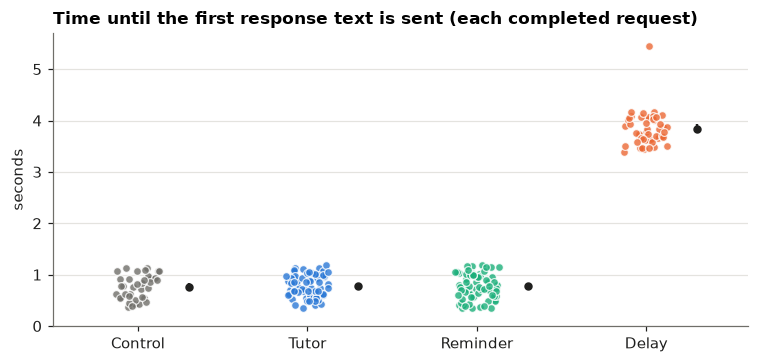

In [19]:
display(completed.groupby('condition', observed=True)[
    ['time_to_first_token_ms', 'artificial_delay_ms', 'server_first_emit_ms']].median().round(0))

fig, ax = plt.subplots(figsize=(7, 3.4))
strip_by_condition(ax, completed.assign(first_emit_s=completed['server_first_emit_ms'] / 1000), 'first_emit_s',
                   'seconds', 'Time until the first response text is sent (each completed request)', seed=3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [20]:
print('Share of requests with the tutor prompt active, by condition and task:')
display(pd.crosstab(requests['condition'], requests['task_title'], values=requests['prompt_active'].astype(float),
                    aggfunc='mean').round(2))

context = data.session_context()[['session_id', 'participant_id', 'condition_key']]
modal_states = label_conditions(data.warning_states.merge(context, on='session_id'))
modal_states['seconds_to_acknowledge'] = (
    modal_states['acknowledged_at_dt'] - modal_states['displayed_at_dt']).dt.total_seconds()
print(f"Reminder participants who started: {analysis['condition'].eq('Reminder').sum()}; "
      f"modal shown: {modal_states['displayed_at'].notna().sum()}; "
      f"acknowledged: {modal_states['acknowledged_at'].notna().sum()}; "
      f"other conditions with a modal: {(modal_states['condition'] != 'Reminder').sum()}")
display(modal_states['seconds_to_acknowledge'].describe().round(1).to_frame().T)

Share of requests with the tutor prompt active, by condition and task:


task_title,02 · Biology: Evidence about osmosis,03 · English: A library investment argument,05 · Geometry: Explain and adapt
condition,,,
Control,0.0,0.0,0.0
Tutor,1.0,1.0,1.0
Reminder,0.0,0.0,0.0
Delay,0.0,0.0,0.0


Reminder participants who started: 11; modal shown: 11; acknowledged: 11; other conditions with a modal: 0


,count,mean,std,min,25%,50%,75%,max
seconds_to_acknowledge,11.0,16.5,5.0,5.7,13.9,18.8,19.8,22.6


`prompt_active` shows the prompt was sent, not that it changed the replies. Here is the first geometry exchange in a Control session and a Tutor session:

In [21]:
transcript = label_conditions(data.chat_transcript()).sort_values(['session_id', 'created_at'])
geometry_title = TASK_LABELS[4]
geometry_chat = transcript[transcript['task_title'].str.contains('Geometry', na=False)]

for cond in ['Control', 'Tutor']:
    session = geometry_chat.loc[geometry_chat['condition'] == cond, 'session_id'].iloc[0]
    turns = geometry_chat[geometry_chat['session_id'] == session]
    student = turns[turns['role'] == 'user'].iloc[0]
    reply = turns[(turns['role'] == 'assistant') & (turns['created_at'] >= student['created_at'])].iloc[0]
    print(f"── {cond} ({student['participant_id']})")
    print('Student:  ' + textwrap.fill(student['text'], 110, subsequent_indent='          '))
    print('AI:       ' + textwrap.fill(textwrap.shorten(reply['text'], 600), 110, subsequent_indent='          '))
    print()

── Control (P-D5129A0043A8)
Student:  if the sides are 3 times bigger why is the area 9 times
AI:       Because area uses two dimensions. The base gets 3 times longer and the height gets 3 times longer, so the area
          becomes 3 × 3 = 9 times bigger: 12 × 9 = 108 cm².

── Tutor (P-0C4B17997AB5)
Student:  is the area 9 times bigger because 3 squared?
AI:       You're on the right track! Can you explain *why* it's 3 squared using the triangle area formula? What happens
          to the base and the height when every side is tripled?



H1 holds:

- Delay responses start about 3 s later. Provider time is the same in all conditions.
- The tutor prompt is active on all Tutor requests and no others.
- All 11 Reminder students saw and acknowledged the modal within 25 s.

## 6. H2: prompting

The outcome is the number of prompts in the two question tasks. Dropouts started fewer question tasks, so the model is a Poisson GLM with log(question tasks started) as an offset, adjusted for prior AI use. If the data are overdispersed, a negative binomial model is used instead. Kruskal–Wallis serves as a non-parametric check.

In [22]:
h2 = analysis.dropna(subset=['ai_use_freq'])
h2 = h2[h2['question_tasks_started'] > 0].copy()
h2['log_exposure'] = np.log(h2['question_tasks_started'].astype('float64'))
h2['prompts_question'] = h2['prompts_question'].astype('float64')
formula = 'prompts_question ~ C(condition, Treatment("Control")) + ai_use_freq'

poisson = smf.glm(formula, data=h2, family=sm.families.Poisson(), offset=h2['log_exposure']).fit()
dispersion = poisson.pearson_chi2 / poisson.df_resid
print(f'Poisson dispersion (Pearson χ² / df): {dispersion:.2f}')
if dispersion > 1.5:
    count_model = smf.negativebinomial(formula, data=h2, offset=h2['log_exposure']).fit(disp=False)
    print('Overdispersed -> negative binomial model.')
else:
    count_model = poisson
    print('No meaningful overdispersion -> Poisson model.')

h2_contrasts = contrast_table(count_model, exponentiate=True).rename(columns={'estimate': 'rate_ratio'})
h2_wald = condition_wald(count_model)
h2_kw = stats.kruskal(*[g['prompts_per_qtask'].dropna() for _, g in h2.groupby('condition', observed=True)])
display(h2_contrasts)
print(f'Joint test of condition: Wald χ² = {h2_wald[0]:.2f}, p = {h2_wald[1]:.4f};  '
      f'Kruskal–Wallis H = {h2_kw.statistic:.2f}, p = {h2_kw.pvalue:.4f}')

Poisson dispersion (Pearson χ² / df): 1.32
No meaningful overdispersion -> Poisson model.


,rate_ratio,ci_low,ci_high,p
Tutor,1.453,0.919,2.298,0.110
Reminder,1.227,0.774,1.947,0.384
Delay,1.042,0.638,1.703,0.868


Joint test of condition: Wald χ² = 3.60, p = 0.3078;  Kruskal–Wallis H = 6.01, p = 0.1113


A rate ratio of 1.5 means 50% more prompts per question task than Control.

Below are timelines for a typical Tutor student and a typical Delay student (prompt count closest to the condition median), built from `session_timeline()` and `focus_periods()`.

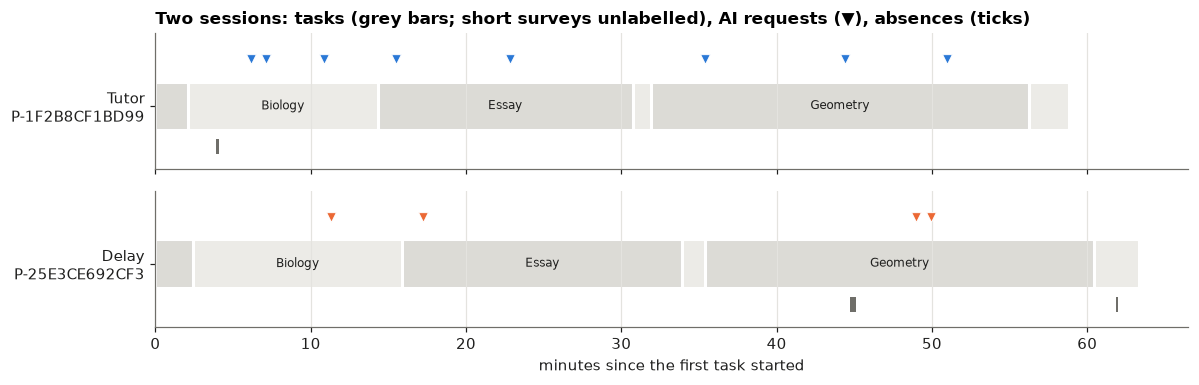

In [23]:
def typical_session(cond):
    group = analysis[(analysis['condition'] == cond) & analysis['state'].eq('COMPLETED')]
    return (group['prompts_question'] - group['prompts_question'].median()).abs().idxmin()


fig, axes = plt.subplots(2, 1, figsize=(11, 3.6), sharex=True)
for ax, cond in zip(axes, ['Tutor', 'Delay']):
    session = typical_session(cond)
    timeline = data.session_timeline(session)
    session_tasks = tasks[tasks['session_id'] == session].sort_values('position')
    t0 = session_tasks['started_at_dt'].min()

    def to_min(timestamps, t0=t0):
        return (timestamps - t0).dt.total_seconds() / 60

    for i, (_, task) in enumerate(session_tasks.iterrows()):
        start, end = to_min(pd.Series([task['started_at_dt'], task['completed_at_dt']]))
        ax.barh(0, end - start, left=start, height=0.5, color='#ecebe7' if i % 2 else '#dcdbd6',
                edgecolor='white', lw=2)
        if end - start >= 4:
            ax.text((start + end) / 2, 0, TASK_LABELS[task['position']], ha='center', va='center', fontsize=8,
                    color=INK)
    prompts_at = to_min(timeline.loc[timeline['event_kind'] == 'llm_request', 'occurred_at_dt'])
    ax.scatter(prompts_at, np.full(len(prompts_at), 0.48), marker='v', s=40, color=COLORS[cond], zorder=3,
               edgecolor='white', linewidth=0.6, label='AI request')
    for _, away in focus[focus['session_id'] == session].iterrows():
        ax.barh(-0.42, max(away['away_s'] / 60, 0.15), left=to_min(pd.Series([away['away_at_dt']])).iloc[0],
                height=0.16, color=MUTED)
    ax.set_yticks([0], [f"{cond}\n{df.loc[session, 'participant_id']}"])
    ax.set_ylim(-0.65, 0.75)
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', visible=True)
axes[0].set_title('Two sessions: tasks (grey bars; short surveys unlabelled), AI requests (▼), absences (ticks)')
axes[1].set_xlabel('minutes since the first task started')
plt.tight_layout()
plt.show()

## 7. H3: performance

ANCOVA for each subject score:

`score ~ condition + baseline confidence + prior AI use`

The model uses HC3 robust standard errors. Coefficients are percentage-point differences from Control.

In [24]:
h3_formula = '{outcome} ~ C(condition, Treatment("Control")) + conf_pre + ai_use_freq'
h3_models, h3_contrasts = {}, []
for outcome in ['biology_pct', 'geometry_pct']:
    sample = analysis.dropna(subset=[outcome, 'conf_pre', 'ai_use_freq'])
    model = smf.ols(h3_formula.format(outcome=outcome), data=sample).fit(cov_type='HC3')
    h3_models[outcome] = model
    f_stat, p = condition_wald(model)
    print(f'{outcome}: n = {int(model.nobs)}, R² = {model.rsquared:.2f}, '
          f'joint test of condition F = {f_stat:.2f}, p = {p:.3f}')
    h3_contrasts.append(contrast_table(model).assign(outcome=outcome))
h3_contrasts = pd.concat(h3_contrasts)
display(h3_contrasts.round(3))

biology_pct: n = 38, R² = 0.54, joint test of condition F = 0.52, p = 0.671
geometry_pct: n = 36, R² = 0.48, joint test of condition F = 1.44, p = 0.249


,estimate,ci_low,ci_high,p,outcome
Tutor,-5.945,-22.141,10.251,0.472,biology_pct
Reminder,-7.777,-22.654,7.099,0.306,biology_pct
Delay,-11.175,-29.559,7.208,0.233,biology_pct
Tutor,3.490,-9.542,16.523,0.600,geometry_pct
Reminder,-3.554,-17.681,10.573,0.622,geometry_pct
Delay,-13.013,-33.716,7.691,0.218,geometry_pct


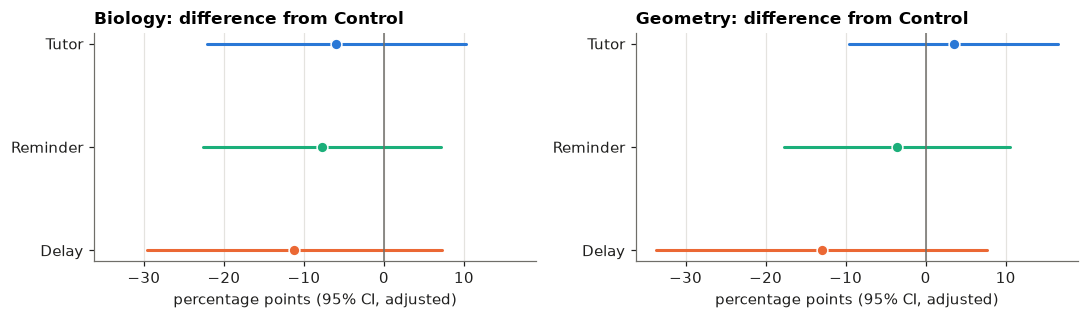

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True)
for ax, outcome in zip(axes, ['biology_pct', 'geometry_pct']):
    rows = h3_contrasts[h3_contrasts['outcome'] == outcome].reindex(CONDITIONS[1:])
    for y, (cond, row) in enumerate(rows.iterrows()):
        ax.plot([row['ci_low'], row['ci_high']], [y, y], color=COLORS[cond], lw=2, solid_capstyle='round')
        ax.scatter(row['estimate'], y, s=50, color=COLORS[cond], edgecolor='white', linewidth=1, zorder=3)
    ax.axvline(0, color=MUTED, lw=1)
    ax.set_yticks(range(3), CONDITIONS[1:])
    ax.invert_yaxis()
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', visible=True)
    ax.set_title(outcome.replace('_pct', '').title() + ': difference from Control')
    ax.set_xlabel('percentage points (95% CI, adjusted)')
plt.tight_layout()
plt.show()

Mean share of points per item. Items marked ✎ are graded manually.

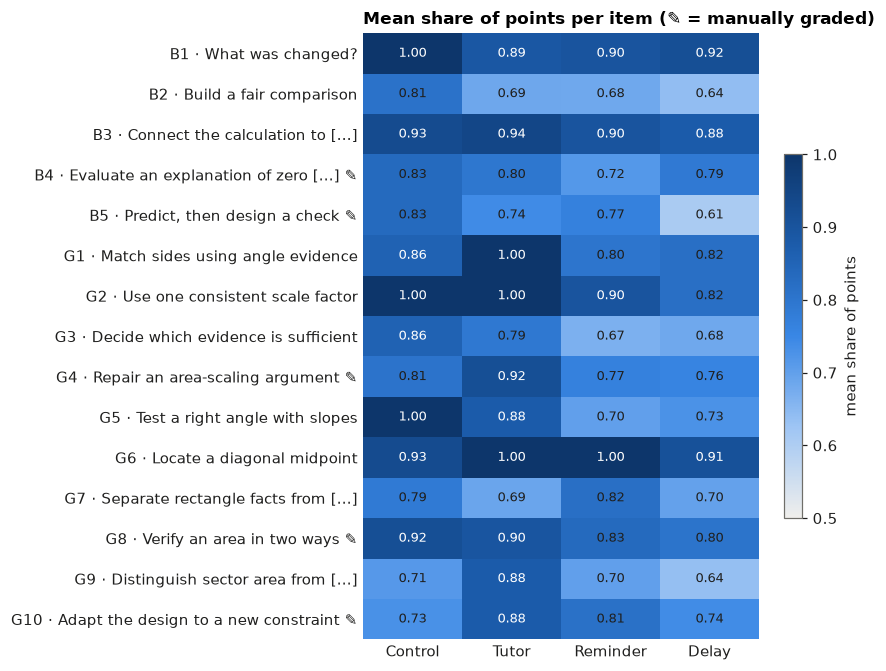

In [26]:
item_means = graded.pivot_table(index='question_title', columns='condition', values='score_fraction', aggfunc='mean',
                                observed=True)
order = graded.drop_duplicates('question_title').sort_values(['task_position', 'question_position'])
item_means = item_means.reindex(index=order['question_title'], columns=CONDITIONS).astype('float64')
modes = order.set_index('question_title')['grading_mode']

fig, ax = plt.subplots(figsize=(8, 6.2))
# Item means sit between about 0.6 and 1, so the colour scale starts at 0.5 to keep differences visible.
image = ax.imshow(item_means.to_numpy(), cmap=BLUES, vmin=0.5, vmax=1, aspect='auto')
for (i, j), value in np.ndenumerate(item_means.to_numpy()):
    ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=8.5, color='white' if value > 0.85 else INK)
fig.colorbar(image, ax=ax, shrink=0.6, label='mean share of points')
ax.set_xticks(range(len(CONDITIONS)), CONDITIONS)
ax.set_yticks(range(len(item_means)), [textwrap.shorten(t, 42) + (' ✎' if modes[t] == 'MANUAL' else '')
                                       for t in item_means.index])
ax.tick_params(length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Mean share of points per item (✎ = manually graded)')
plt.tight_layout()
plt.show()

## 8. H4: perception

Trust in AI was rated before and after. A Wilcoxon signed-rank test checks for change within each condition. An ANCOVA of post-trust, adjusted for pre-trust, compares conditions.

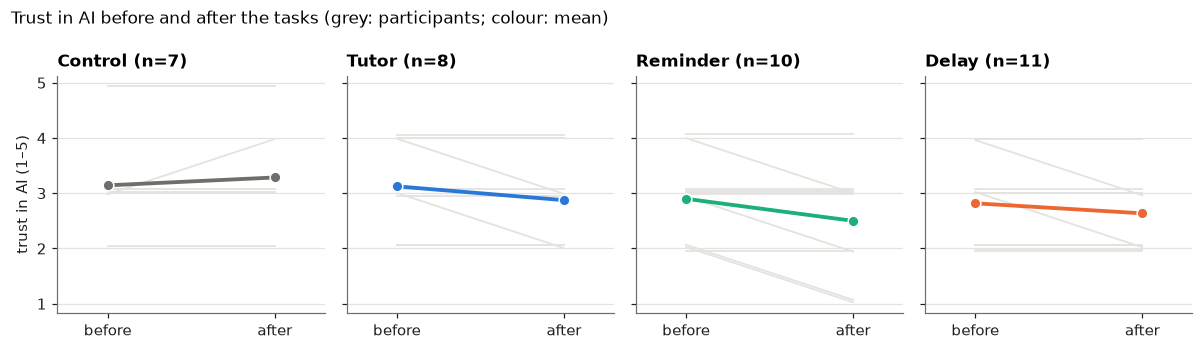

,n,mean_change,p_wilcoxon
condition,,,
Control,7,0.143,1.000
Tutor,8,-0.250,0.500
Reminder,10,-0.400,0.125
Delay,11,-0.182,0.500


,estimate,ci_low,ci_high,p
Tutor,-0.394,-0.853,0.065,0.092
Reminder,-0.563,-1.037,-0.089,0.020
Delay,-0.351,-0.769,0.067,0.100


Joint test of condition on post-trust (adjusted for baseline): F = 1.99, p = 0.1358


In [27]:
fig, axes = plt.subplots(1, 4, figsize=(11, 3.2), sharey=True)
jitter = np.random.default_rng(4)
for ax, cond in zip(axes, CONDITIONS):
    rows = analysis[analysis['condition'] == cond].dropna(subset=['trust_pre', 'trust_post'])
    offsets = jitter.uniform(-0.08, 0.08, len(rows))
    for (_, row), offset in zip(rows.iterrows(), offsets):
        ax.plot([0, 1], [row['trust_pre'] + offset, row['trust_post'] + offset], color=GRID, lw=1.2, zorder=1)
    ax.plot([0, 1], [rows['trust_pre'].mean(), rows['trust_post'].mean()], color=COLORS[cond], lw=2.5, marker='o',
            ms=7, markeredgecolor='white', zorder=3)
    ax.set_xticks([0, 1], ['before', 'after'])
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(f'{cond} (n={len(rows)})')
axes[0].set_ylabel('trust in AI (1–5)')
fig.suptitle('Trust in AI before and after the tasks (grey: participants; colour: mean)',
             x=0.01, ha='left', fontsize=11)
plt.tight_layout()
plt.show()

within = []
for cond, rows in analysis.dropna(subset=['trust_pre', 'trust_post']).groupby('condition', observed=True):
    diff = rows['trust_post'] - rows['trust_pre']
    test = stats.wilcoxon(rows['trust_post'], rows['trust_pre'], zero_method='pratt') if diff.ne(0).any() else None
    within.append({'condition': cond, 'n': len(rows), 'mean_change': diff.mean(),
                   'p_wilcoxon': test.pvalue if test else np.nan})
display(pd.DataFrame(within).set_index('condition').round(3))

trust_model = smf.ols('trust_post ~ C(condition, Treatment("Control")) + trust_pre',
                      data=analysis.dropna(subset=['trust_pre', 'trust_post'])).fit(cov_type='HC3')
trust_wald = condition_wald(trust_model)
display(contrast_table(trust_model).round(3))
print(f'Joint test of condition on post-trust (adjusted for baseline): '
      f'F = {trust_wald[0]:.2f}, p = {trust_wald[1]:.4f}')

*Waiting interrupted* (optional) and *essay effort* are single 1–5 ratings, so they are compared with Kruskal–Wallis. Delay vs Control uses Mann–Whitney, with rank-biserial *r* as the effect size.

In [28]:
def rank_comparison(column):
    groups = {cond: g[column].dropna() for cond, g in analysis.groupby('condition', observed=True)}
    kw = stats.kruskal(*groups.values())
    mw = stats.mannwhitneyu(groups['Delay'], groups['Control'], alternative='two-sided')
    r = 2 * mw.statistic / (len(groups['Delay']) * len(groups['Control'])) - 1
    summary = pd.DataFrame({cond: {'n': len(v), 'median': v.median(), 'mean': v.mean()} for cond, v in groups.items()})
    return summary, kw, mw, r


wait_summary, wait_kw, wait_mw, wait_r = rank_comparison('wait_interrupt')
display(wait_summary.round(2))
print(f'Waiting interrupted – Kruskal–Wallis H = {wait_kw.statistic:.2f}, p = {wait_kw.pvalue:.4f}; '
      f'Delay vs Control: U = {wait_mw.statistic:.1f}, p = {wait_mw.pvalue:.4f}, rank-biserial r = {wait_r:.2f}')

effort_summary, effort_kw, _, _ = rank_comparison('essay_effort')
display(effort_summary.round(2))
print(f'Essay mental effort – Kruskal–Wallis H = {effort_kw.statistic:.2f}, p = {effort_kw.pvalue:.4f}')

,Control,Tutor,Reminder,Delay
n,6.00,7.00,9.00,9.0
median,1.00,2.00,2.00,3.0
mean,1.17,1.57,1.67,3.0


Waiting interrupted – Kruskal–Wallis H = 17.04, p = 0.0007; Delay vs Control: U = 52.5, p = 0.0022, rank-biserial r = 0.94


,Control,Tutor,Reminder,Delay
n,7.00,9.00,10.0,11.00
median,3.00,3.00,3.0,3.00
mean,2.71,3.33,3.4,2.91


Essay mental effort – Kruskal–Wallis H = 7.50, p = 0.0575


## 9. H5: pasting and process (exploratory)

This section uses telemetry only, so the session without it is dropped. The outcome is the free-text score, since those items require written reasoning. Only four students pasted AI text, so the results are descriptive.

Spearman ρ = -0.35 (p = 0.034); pasters (n=4) median 69% vs non-pasters (n=33) 84%, Mann–Whitney p = 0.037


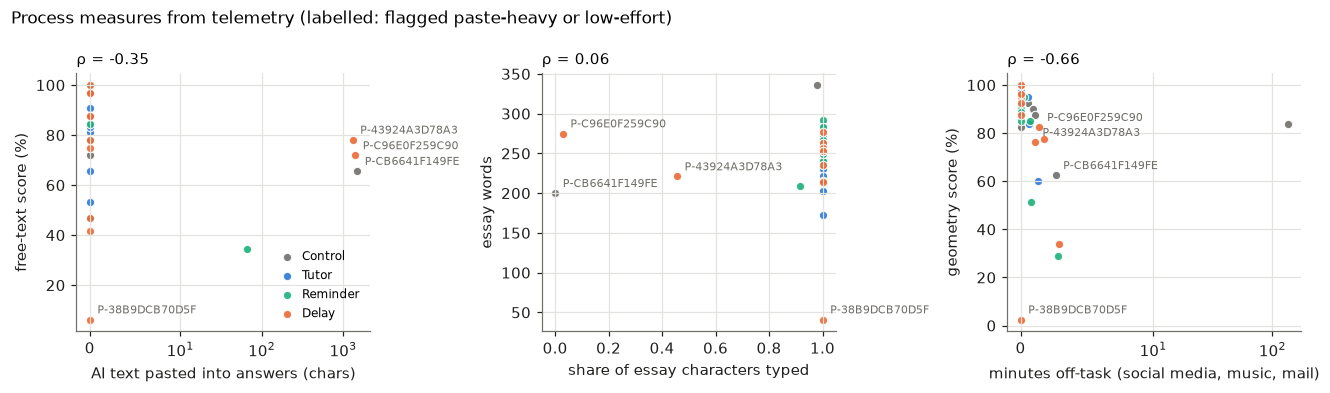

In [29]:
h5 = analysis[analysis['telemetry_ok']].dropna(subset=['freetext_pct'])
rho = stats.spearmanr(h5['ai_paste_chars_question'], h5['freetext_pct'])
pasted = h5['ai_paste_chars_question'] > 0
paste_mw = stats.mannwhitneyu(h5.loc[pasted, 'freetext_pct'], h5.loc[~pasted, 'freetext_pct'])
print(f'Spearman ρ = {rho.statistic:.2f} (p = {rho.pvalue:.3f}); pasters (n={pasted.sum()}) median '
      f"{h5.loc[pasted, 'freetext_pct'].median():.0f}% vs non-pasters (n={(~pasted).sum()}) "
      f"{h5.loc[~pasted, 'freetext_pct'].median():.0f}%, Mann–Whitney p = {paste_mw.pvalue:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
panels = [
    ('ai_paste_chars_question', 'freetext_pct', 'AI text pasted into answers (chars)', 'free-text score (%)', 'symlog'),
    ('essay_typed_share', 'essay_words', 'share of essay characters typed', 'essay words', None),
    ('off_task_min', 'geometry_pct', 'minutes off-task (social media, music, mail)', 'geometry score (%)', 'symlog'),
]
for ax, (x, y, xlabel, ylabel, xscale) in zip(axes, panels):
    rows = h5.dropna(subset=[x, y])
    for cond in CONDITIONS:
        part = rows[rows['condition'] == cond]
        ax.scatter(part[x], part[y], s=30, color=COLORS[cond], edgecolor='white', linewidth=0.8, label=cond, alpha=0.9)
    for session, row in rows[flags.loc[rows.index, 'paste_heavy'] | flags.loc[rows.index, 'low_effort']].iterrows():
        ax.annotate(row['participant_id'], (row[x], row[y]), xytext=(5, 4), textcoords='offset points',
                    fontsize=7.5, color=MUTED)
    if xscale:
        ax.set_xscale(xscale, linthresh=10)
    corr = stats.spearmanr(rows[x], rows[y])
    ax.set_title(f'ρ = {corr.statistic:.2f}', fontsize=10, fontweight='normal')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis='x', visible=True)
axes[0].legend(loc='lower right', fontsize=8, handletextpad=0.2)
fig.suptitle('Process measures from telemetry (labelled: flagged paste-heavy or low-effort)',
             x=0.01, ha='left', fontsize=11)
plt.tight_layout()
plt.show()

Middle panel: essays of the same length can be typed or mostly pasted. Typed share shows the difference, which word count cannot.

## 10. Robustness

The geometry model from H3 is refitted on four samples: all participants, without the low-effort student, also without the paste-heavy students, and completers only. Then come a permutation test (5,000 shuffles) and a power analysis.

In [30]:
flagged = flags.loc[analysis.index]
SAMPLES = {
    'All analysable': analysis.index,
    'Excl. low effort': analysis.index[~flagged['low_effort']],
    'Excl. low effort + paste-heavy': analysis.index[~flagged[['low_effort', 'paste_heavy']].any(axis=1)],
    'Completers only': analysis.index[analysis['state'].eq('COMPLETED')],
}
robust_rows = []
for name, index in SAMPLES.items():
    sample = analysis.loc[index].dropna(subset=['geometry_pct', 'conf_pre', 'ai_use_freq'])
    model = smf.ols(h3_formula.format(outcome='geometry_pct'), data=sample).fit(cov_type='HC3')
    table = contrast_table(model)
    row = {cond: f"{r['estimate']:+.1f} [{r['ci_low']:+.1f}, {r['ci_high']:+.1f}]" for cond, r in table.iterrows()}
    robust_rows.append({'sample': name, 'n': int(model.nobs), **row, 'joint p': condition_wald(model)[1]})
display(pd.DataFrame(robust_rows).set_index('sample').round(3))

,n,Tutor,Reminder,Delay,joint p
sample,,,,,
All analysable,36,"+3.5 [-9.5, +16.5]","-3.6 [-17.7, +10.6]","-13.0 [-33.7, +7.7]",0.249
Excl. low effort,35,"+3.3 [-8.8, +15.5]","-3.6 [-17.5, +10.2]","-6.2 [-21.6, +9.3]",0.284
Excl. low effort + paste-heavy,32,"+4.1 [-9.4, +17.5]","-2.9 [-17.1, +11.3]","-4.3 [-21.5, +12.9]",0.453
Completers only,35,"+3.9 [-11.4, +19.2]","-3.1 [-19.2, +13.0]","-12.6 [-34.9, +9.8]",0.253


The Tutor and Reminder estimates stay stable. The Delay gap falls from −13 to −6 points without the low-effort student, and to −4 without the paste-heavy students. A few individuals drive it.

In [31]:
perm = analysis.dropna(subset=['geometry_pct', 'conf_pre', 'ai_use_freq'])
y = perm['geometry_pct'].to_numpy(float)
covariates = np.column_stack([np.ones(len(perm)), perm[['conf_pre', 'ai_use_freq']].to_numpy(float)])
labels = perm['condition'].to_numpy()


def rss(X):
    return np.sum((y - X @ np.linalg.lstsq(X, y, rcond=None)[0]) ** 2)


def condition_f(labels):
    dummies = np.column_stack([(labels == cond).astype(float) for cond in CONDITIONS[1:]])
    full = np.column_stack([covariates, dummies])
    rss_full, rss_reduced = rss(full), rss(covariates)
    return ((rss_reduced - rss_full) / dummies.shape[1]) / (rss_full / (len(y) - full.shape[1]))


rng = np.random.default_rng(SEED)
observed_f = condition_f(labels)
null_f = np.array([condition_f(rng.permutation(labels)) for _ in range(5000)])
perm_p = (1 + np.sum(null_f >= observed_f)) / (1 + len(null_f))

# Unadjusted one-way effect size (Cohen's f) and the smallest effect this design detects with 80% power.
eta_sq = smf.ols('geometry_pct ~ C(condition)', data=perm).fit().rsquared
observed_cohens_f = np.sqrt(eta_sq / (1 - eta_sq))
detectable_f = FTestAnovaPower().solve_power(effect_size=None, nobs=len(perm), alpha=0.05, power=0.8, k_groups=4)
print(f'Permutation test (5,000 shuffles): F = {observed_f:.2f}, p = {perm_p:.3f}')
print(f"Observed Cohen's f = {observed_cohens_f:.2f}; "
      f'detectable with 80% power at n = {len(perm)}: f = {detectable_f:.2f} '
      '(Cohen: 0.10 small, 0.25 medium, 0.40 large)')
power_now = FTestAnovaPower().power(effect_size=observed_cohens_f, nobs=len(perm), alpha=0.05, k_groups=4)
needed = FTestAnovaPower().solve_power(effect_size=observed_cohens_f, nobs=None, alpha=0.05, power=0.8, k_groups=4)
print(f'Power for the observed effect: {power_now:.0%}; '
      f'participants needed for 80% power: about {int(np.ceil(needed))}')

Permutation test (5,000 shuffles): F = 1.55, p = 0.203
Observed Cohen's f = 0.23; detectable with 80% power at n = 36: f = 0.59 (Cohen: 0.10 small, 0.25 medium, 0.40 large)
Power for the observed effect: 16%; participants needed for 80% power: about 217


## 11. Results

Holm correction across the H2–H4 tests. H1 (manipulation check) and H5 (exploratory) are not included.

In [32]:
family = pd.DataFrame([
    ('H2', 'Prompt rate per question task (count model)', 'Wald χ²', h2_wald[1]),
    ('H2', 'Prompts per question task', 'Kruskal–Wallis', h2_kw.pvalue),
    ('H3', 'Biology score (adjusted)', 'Robust F', condition_wald(h3_models['biology_pct'])[1]),
    ('H3', 'Geometry score (adjusted)', 'Robust F', condition_wald(h3_models['geometry_pct'])[1]),
    ('H4', 'Post trust, adjusted for baseline', 'Robust F', trust_wald[1]),
    ('H4', 'Waiting interrupted', 'Kruskal–Wallis', wait_kw.pvalue),
    ('H4', 'Waiting interrupted: Delay vs Control', 'Mann–Whitney', wait_mw.pvalue),
    ('H4', 'Essay mental effort', 'Kruskal–Wallis', effort_kw.pvalue),
], columns=['hypothesis', 'outcome', 'test', 'p'])
family['p_holm'] = multipletests(family['p'], method='holm')[1]
family['significant (Holm, α = .05)'] = family['p_holm'] < 0.05
display(family.set_index(['hypothesis', 'outcome']).style.format({'p': '{:.4f}', 'p_holm': '{:.4f}'}))

### Summary

These numbers come from the synthetic cohort and need updating if the export changes.

- **H1, confirmed.** Delay added 3 s (3.8 s vs 0.75 s to first output). The tutor prompt reached all Tutor requests and no others. All Reminder students acknowledged the modal.
- **H2, not significant.** Tutor students sent about 45% more prompts per question task than Control (rate ratio 1.45, 95% CI 0.92–2.30). The tutor replies with questions, which leads to more turns. Delay matched Control (1.04).
- **H3, no detectable difference.** All CIs include zero. The Delay geometry gap comes from two or three students (section 10). With n = 36 the design detects only f ≈ 0.6, and the observed f ≈ 0.23 would need about 217 participants. The null result says little.
- **H4, waiting: significant after correction.** Delay students rated waiting as more disruptive (median 3 vs 1, r ≈ 0.9). Trust fell slightly in all three intervention groups and rose slightly in Control. Reminder was 0.56 points lower than Control after adjustment (95% CI −1.04 to −0.09), but the joint test was not significant. Essay effort was higher under Tutor and Reminder (p ≈ .06, uncorrected).
- **H5, suggestive.** The four students who pasted AI text scored lower on free-text items (median 69% vs 84%, ρ = −0.35, p = .03 uncorrected), and their essays were mostly pasted. More off-task time also went with lower geometry scores.

The conditions changed the experience, and students noticed the delay. The sample is too small to show effects on scores.

### Limitations

- Synthetic data; 39 participants in four groups.
- Token counts are estimated from characters.
- Client timestamps can be off by a few seconds.
- Five manual items were not graded at export time.
- One session has no telemetry.
- Thresholds (20 min, 100 words, 1,000 characters, 60% overlap) were set in advance; section 10 shows their effect.

## 12. Export

Saves the participant table and the source tables with `materialize()`. The cell writes to a temporary directory; change `OUTPUT_DIR` to keep the files.

In [33]:
with TemporaryDirectory() as directory:
    OUTPUT_DIR = Path(directory)
    participant_table = analysis.join(flags).reset_index()
    participant_table.to_parquet(OUTPUT_DIR / 'participant_analysis.parquet', index=False)
    manifest = data.materialize(OUTPUT_DIR / 'tables', format='parquet', tables=[
        'sessions', 'conditions', 'session_tasks', 'question_responses', 'survey_responses', 'llm_requests',
        'telemetry_summaries', 'warning_states',
    ])
    print(f'participant_analysis.parquet: {len(participant_table)} rows x {participant_table.shape[1]} columns')
    display(pd.DataFrame(manifest['tables']).T[['file', 'rows']])

PACKAGES = ['open-webui-research-toolbox', 'pandas', 'numpy', 'scipy', 'statsmodels', 'matplotlib']
display(pd.Series({package: version(package) for package in PACKAGES}, name='version').to_frame())

participant_analysis.parquet: 39 rows x 48 columns


,file,rows
sessions,sessions.parquet,40
conditions,conditions.parquet,4
session_tasks,session_tasks.parquet,240
question_responses,question_responses.parquet,565
survey_responses,survey_responses.parquet,486
llm_requests,llm_requests.parquet,234
telemetry_summaries,telemetry_summaries.parquet,38
warning_states,warning_states.parquet,11


,version
open-webui-research-toolbox,0.2.0
pandas,3.0.6
numpy,2.5.3
scipy,1.18.1
statsmodels,0.15.0
matplotlib,3.11.2
